### Compare reforestation v natural regeneration under two future climate scenarios

In [7]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

In [8]:
#fates_nat_ssp1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp1_nat_regrowth.Ea8fbc2fc28-Ff46de7a5.2025-06-20/run/PA_ssp1_nat_regrowth.Ea8fbc2fc28-Ff46de7a5.2025-06-20.sofar.nc'
fates_nat_ssp1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp1_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_ssp1_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'
fates_nat_ssp1 = xr.open_dataset(fates_nat_ssp1,  decode_times=False)

#fates_ref_ssp1 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20/run/PA_ssp1_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20.sofar.nc'
fates_ref_ssp1 =  '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp1_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_ssp1_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'
fates_ref_ssp1 = xr.open_dataset(fates_ref_ssp1,  decode_times=False)

#fates_nat_ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp5_nat_regrowth.Ea8fbc2fc28-Ff46de7a5.2025-06-20/run/PA_ssp5_nat_regrowth.Ea8fbc2fc28-Ff46de7a5.2025-06-20.sofar.nc'
fates_nat_ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp5_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_ssp5_nat_regrowth.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'
fates_nat_ssp5 = xr.open_dataset(fates_nat_ssp5,  decode_times=False)

#fates_ref_ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v6/PA_ssp5_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20/run/PA_ssp5_reforest.Ea8fbc2fc28-Ff46de7a5.2025-06-20.sofar.nc'
fates_ref_ssp5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_ssp5_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_ssp5_reforest.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'
fates_ref_ssp5 = xr.open_dataset(fates_ref_ssp5,  decode_times=False)


In [9]:
nyears = int(len(fates_nat_ssp1.variables['time'])/12)
time_nat = fates_nat_ssp1.variables['time'] / 365.
time_ref = fates_ref_ssp1.variables['time'] / 365.
time_ref5 = fates_ref_ssp5.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates_nat_ssp1.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates_nat_ssp1.variables['fates_levage'][:]

In [10]:
print(nyears)
print(tave_start)
print(tave_stop)

80
720
960


In [11]:
AGB_nat_ssp1 = fates_nat_ssp1.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_nat_ssp1 = AGB_nat_ssp1.sum(dim='fates_levscpf')

AGB_ref_ssp1 = fates_ref_ssp1.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_ref_ssp1 = AGB_ref_ssp1.sum(dim='fates_levscpf')

AGB_nat_ssp5 = fates_nat_ssp5.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_nat_ssp5 = AGB_nat_ssp5.sum(dim='fates_levscpf')

AGB_ref_ssp5 = fates_ref_ssp5.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_ref_ssp5 = AGB_ref_ssp5.sum(dim='fates_levscpf')


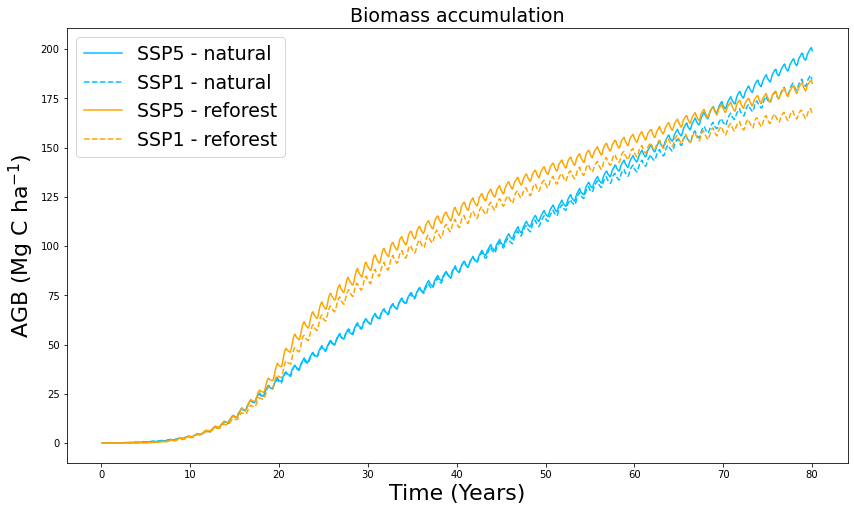

In [12]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(14,8))

f1ax0.plot(time_nat, AGB_nat_ssp5,label = 'SSP5 - natural', color='deepskyblue')    
f1ax0.plot(time_nat, AGB_nat_ssp1,label = 'SSP1 - natural', linestyle='--', color='deepskyblue')    
f1ax0.plot(time_ref5, AGB_ref_ssp5, label = 'SSP5 - reforest', color='orange') 
f1ax0.plot(time_ref, AGB_ref_ssp1, label = 'SSP1 - reforest', linestyle='--', color='orange') 

f1ax0.set_title(r'Biomass accumulation', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize=22)

f1ax0.legend(fontsize=19)

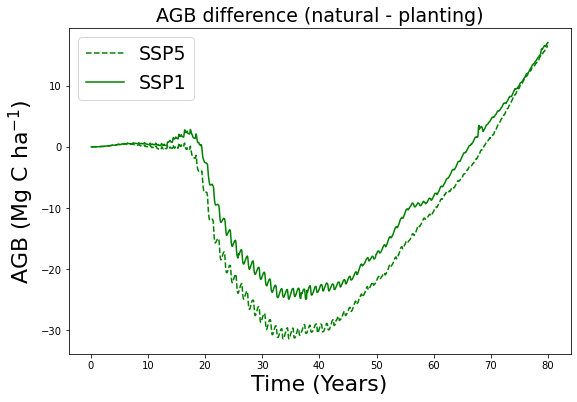

In [7]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(9,6))
f1ax0.plot(time_nat, AGB_nat_ssp5 - AGB_ref_ssp5, color='green', label='SSP5', linestyle='--')
f1ax0.plot(time_nat, AGB_nat_ssp1 - AGB_ref_ssp1, color='green', label='SSP1')

f1ax0.set_title(r'AGB difference (natural - planting)', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize=22)
f1ax0.legend(fontsize=19)

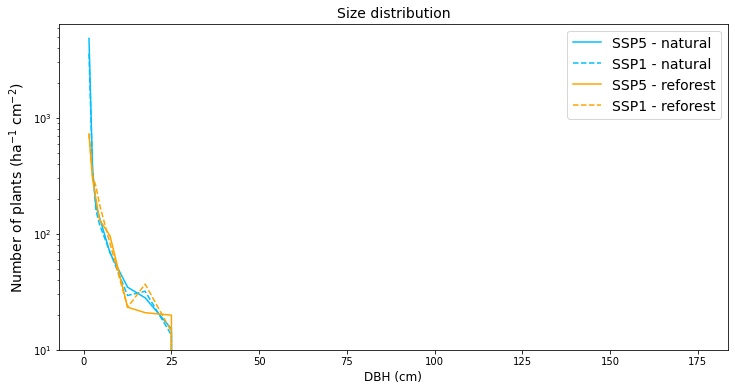

In [8]:
# size bins are LOWER bounds. Remove the fist bin - but add an extra bin to catch trees over last bin edge
cohort_size_bins_ex = np.append(cohort_size_bins[1:], 250)
fates_sizebin_mids = (cohort_size_bins_ex[0:-1] + cohort_size_bins_ex[1:])/2
fates_sizebin_widths = cohort_size_bins_ex[1:] - cohort_size_bins_ex[:-1]

NPLANT_SZ_nat_ssp1 = fates_nat_ssp1.FATES_NPLANT_SZ * 10000
NPLANT_SZ_ref_ssp1 = fates_ref_ssp1.FATES_NPLANT_SZ * 10000

nplant_nat_ssp1 = NPLANT_SZ_nat_ssp1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_nat_ssp1 = np.squeeze(nplant_nat_ssp1)
nplant_nat_ssp1 = np.squeeze(nplant_nat_ssp1[1:,])/fates_sizebin_widths

nplant_ref_ssp1 = NPLANT_SZ_ref_ssp1.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_ref_ssp1 = np.squeeze(nplant_ref_ssp1)
nplant_ref_ssp1 = np.squeeze(nplant_ref_ssp1[1:,])/fates_sizebin_widths

NPLANT_SZ_nat_ssp5 = fates_nat_ssp5.FATES_NPLANT_SZ * 10000
NPLANT_SZ_ref_ssp5 = fates_ref_ssp5.FATES_NPLANT_SZ * 10000

nplant_nat_ssp5 = NPLANT_SZ_nat_ssp5.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_nat_ssp5 = np.squeeze(nplant_nat_ssp5)
nplant_nat_ssp5 = np.squeeze(nplant_nat_ssp5[1:,])/fates_sizebin_widths

nplant_ref_ssp5 = NPLANT_SZ_ref_ssp5.isel(time=slice(tave_start,tave_stop)).mean(dim='time') 
nplant_ref_ssp5 = np.squeeze(nplant_ref_ssp5)
nplant_ref_ssp5 = np.squeeze(nplant_ref_ssp5[1:,])/fates_sizebin_widths



fig2, ((f2ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f2ax0.plot(fates_sizebin_mids, nplant_nat_ssp5,  label = 'SSP5 - natural', color='deepskyblue')
f2ax0.plot(fates_sizebin_mids, nplant_nat_ssp1,  label = 'SSP1 - natural', linestyle='--', color='deepskyblue')
f2ax0.plot(fates_sizebin_mids, nplant_ref_ssp5,  label = 'SSP5 - reforest', color='orange')
f2ax0.plot(fates_sizebin_mids, nplant_ref_ssp1,  label = 'SSP1 - reforest', linestyle='--', color='orange')
   
f2ax0.set_title(r'Size distribution', fontsize = 14)
f2ax0.set_ylabel(r'Number of plants (ha$^{-1}$ cm$^{-2}$)', fontsize = 14)
f2ax0.set_xlabel(r'DBH (cm)', fontsize = 12)    

f2ax0.legend(fontsize=14)
f2ax0.set_yscale('log')
#f2ax0.set_xscale('log')

Text(0, 0.5, 'Cohort Size (cm)')

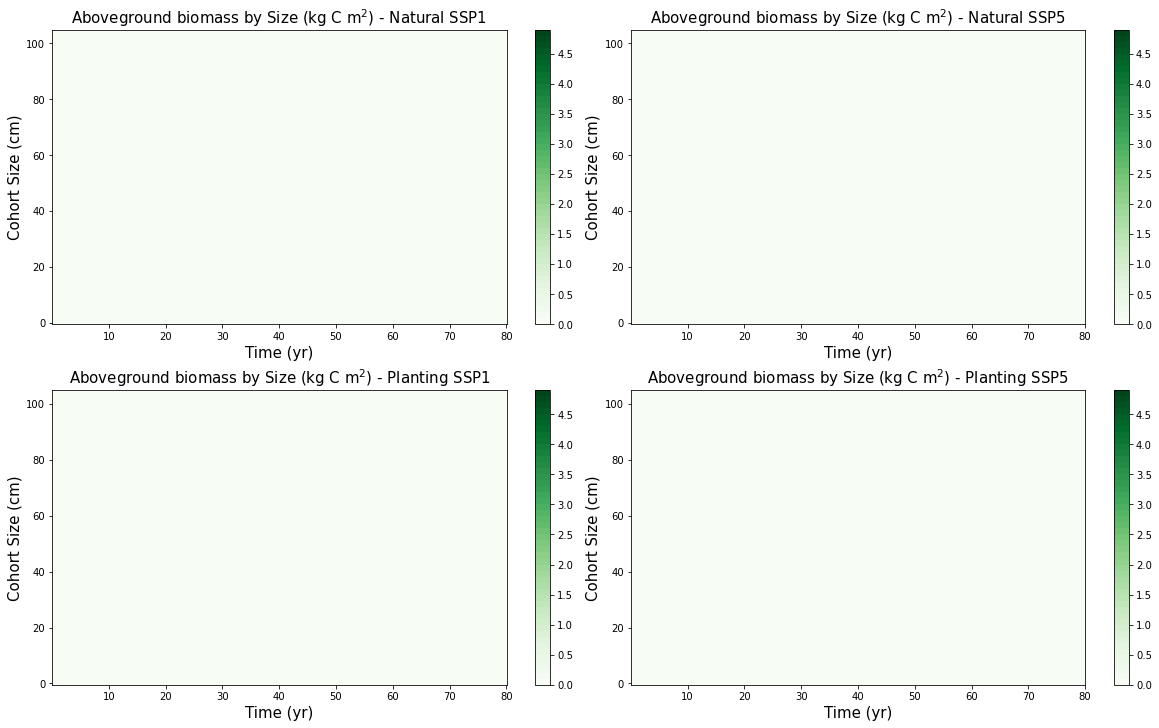

In [9]:
VEGC_ABOVEGROUND_SZPF_nat_ssp1 = fa.scpf_to_scls_by_pft(fates_nat_ssp1.FATES_VEGC_ABOVEGROUND_SZPF, fates_nat_ssp1)
VEGC_ABOVEGROUND_SZ_nat_ssp1  = VEGC_ABOVEGROUND_SZPF_nat_ssp1.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF_ref_ssp1 = fa.scpf_to_scls_by_pft(fates_ref_ssp1.FATES_VEGC_ABOVEGROUND_SZPF, fates_ref_ssp1)
VEGC_ABOVEGROUND_SZ_ref_ssp1  = VEGC_ABOVEGROUND_SZPF_ref_ssp1.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF_nat_ssp5 = fa.scpf_to_scls_by_pft(fates_nat_ssp5.FATES_VEGC_ABOVEGROUND_SZPF, fates_nat_ssp5)
VEGC_ABOVEGROUND_SZ_nat_ssp5  = VEGC_ABOVEGROUND_SZPF_nat_ssp5.sum(dim='fates_levpft')

VEGC_ABOVEGROUND_SZPF_ref_ssp5 = fa.scpf_to_scls_by_pft(fates_ref_ssp5.FATES_VEGC_ABOVEGROUND_SZPF, fates_ref_ssp5)
VEGC_ABOVEGROUND_SZ_ref_ssp5  = VEGC_ABOVEGROUND_SZPF_ref_ssp5.sum(dim='fates_levpft')


fig2, ((f2ax0, f2ax1),(f2ax2,f2ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10),constrained_layout=True)

## set up the first plot: evolution of AGB of plants of a given size
levels = np.arange(0.,5, 0.1)
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)


im = f2ax0.pcolormesh(time_nat, cohort_size_bins, VEGC_ABOVEGROUND_SZ_nat_ssp1[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Natural SSP1', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

## set up the first plot: evolution of AGB of plants of a given size

im = f2ax2.pcolormesh(time_ref, cohort_size_bins, VEGC_ABOVEGROUND_SZ_ref_ssp1[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax2)
f2ax2.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Planting SSP1', fontsize=15)
f2ax2.set_xlabel('Time (yr)', fontsize=15)
f2ax2.set_ylabel('Cohort Size (cm)', fontsize=15)

im = f2ax1.pcolormesh(time_nat, cohort_size_bins, VEGC_ABOVEGROUND_SZ_nat_ssp5[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Natural SSP5', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)

## set up the first plot: evolution of AGB of plants of a given size

im = f2ax3.pcolormesh(time_ref5, cohort_size_bins, VEGC_ABOVEGROUND_SZ_ref_ssp5[:,0,:].transpose(), cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax3)
f2ax3.set_title(r'Aboveground biomass by Size (kg C m$^2$) - Planting SSP5', fontsize=15)
f2ax3.set_xlabel('Time (yr)', fontsize=15)
f2ax3.set_ylabel('Cohort Size (cm)', fontsize=15)



Text(0, 0.5, 'Cohort Size (cm)')

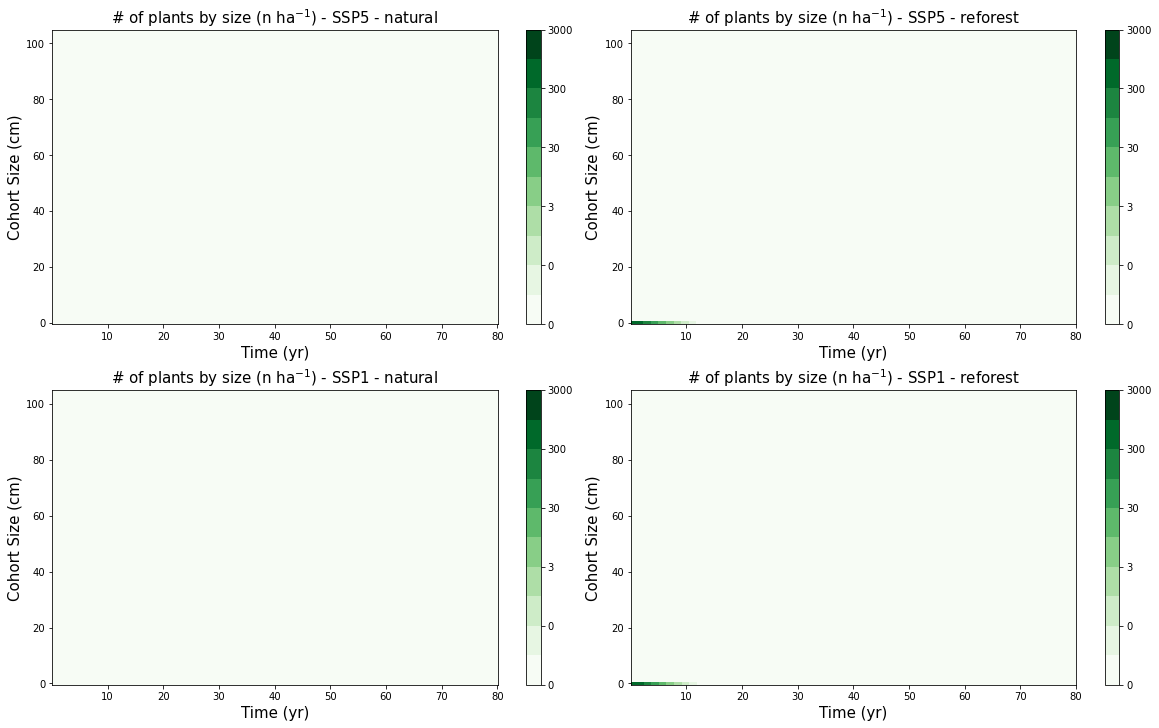

In [10]:
# population numbers as a function of cohort size
NPLANT_SZ_nat_ssp1 = np.squeeze(fates_nat_ssp1.FATES_NPLANT_SZ) * 10000
NPLANT_SZ_ref_ssp1 = np.squeeze(fates_ref_ssp1.FATES_NPLANT_SZ) * 10000

NPLANT_SZ_nat_ssp5 = np.squeeze(fates_nat_ssp5.FATES_NPLANT_SZ) * 10000
NPLANT_SZ_ref_ssp5 = np.squeeze(fates_ref_ssp5.FATES_NPLANT_SZ) * 10000


fig2, ((f2ax0, f2ax1),(f2ax2,f2ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10),constrained_layout=True)

levels = np.array([0, 0.1,0.3,1.,3.,10.,30., 100., 300., 1000., 3000]) # do a pseudo-log scale here
cmap = plt.get_cmap('Greens')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

im = f2ax0.pcolormesh(time_nat, cohort_size_bins, (NPLANT_SZ_nat_ssp5).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax0)
f2ax0.set_title(r'# of plants by size (n ha$^{-1}$) - SSP5 - natural', fontsize=15)
f2ax0.set_xlabel('Time (yr)', fontsize=15)
f2ax0.set_ylabel('Cohort Size (cm)', fontsize=15)

im = f2ax1.pcolormesh(time_ref5, cohort_size_bins, (NPLANT_SZ_ref_ssp5).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax1)
f2ax1.set_title(r'# of plants by size (n ha$^{-1}$) - SSP5 - reforest', fontsize=15)
f2ax1.set_xlabel('Time (yr)', fontsize=15)
f2ax1.set_ylabel('Cohort Size (cm)', fontsize=15)

im = f2ax2.pcolormesh(time_nat, cohort_size_bins, (NPLANT_SZ_nat_ssp1).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax2)
f2ax2.set_title(r'# of plants by size (n ha$^{-1}$) - SSP1 - natural', fontsize=15)
f2ax2.set_xlabel('Time (yr)', fontsize=15)
f2ax2.set_ylabel('Cohort Size (cm)', fontsize=15)

im = f2ax3.pcolormesh(time_ref, cohort_size_bins, (NPLANT_SZ_ref_ssp1).transpose(),
                      cmap=cmap, norm=norm)
fig2.colorbar(im, ax=f2ax3)
f2ax3.set_title(r'# of plants by size (n ha$^{-1}$) - SSP1 - reforest', fontsize=15)
f2ax3.set_xlabel('Time (yr)', fontsize=15)
f2ax3.set_ylabel('Cohort Size (cm)', fontsize=15)

Text(0.5, 1.0, 'Soil carbon')

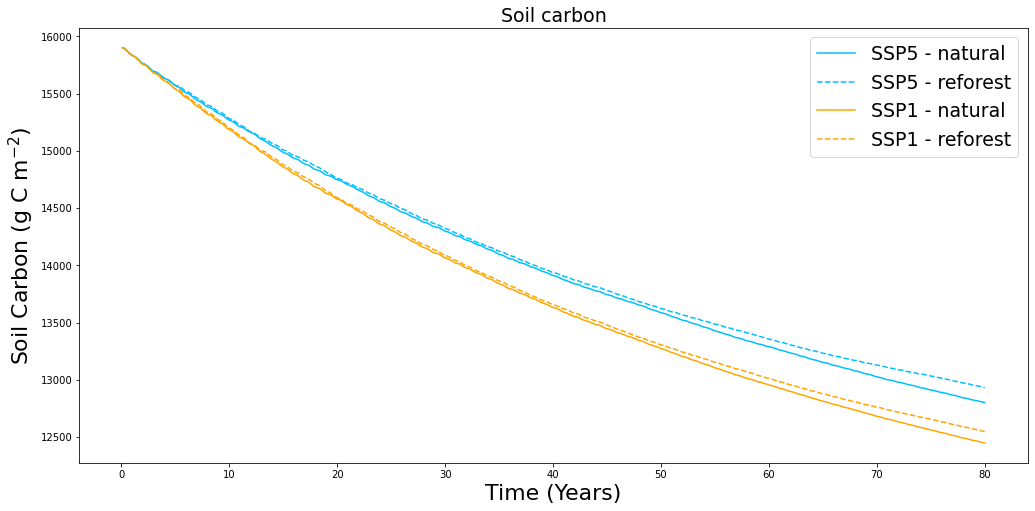

In [11]:
soil_nat_ssp1 = fates_nat_ssp1.SOILC  
soil_ref_ssp1 = fates_ref_ssp1.SOILC
soil_nat_ssp5 = fates_nat_ssp5.SOILC  
soil_ref_ssp5 = fates_ref_ssp5.SOILC

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(17,8))

f1ax0.plot(time_nat, soil_nat_ssp5, color='deepskyblue', label='SSP5 - natural')
f1ax0.plot(time_nat, soil_nat_ssp1, color='deepskyblue', linestyle='--', label='SSP5 - reforest')
f1ax0.plot(time_ref5, soil_ref_ssp5, color='orange', label = 'SSP1 - natural')
f1ax0.plot(time_ref, soil_ref_ssp1, color='orange', linestyle='--', label = 'SSP1 - reforest')    

f1ax0.legend(fontsize=19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'Soil Carbon (g C m$^{-2}$)', fontsize=22)
f1ax0.set_title(r'Soil carbon', fontsize = 19)


### Number of plants through time

In [12]:
NPLANT_SZ_nat_ssp1 = fates_nat_ssp1.FATES_NPLANT_SZ.sum(dim='fates_levscls') * 10000
NPLANT_SZ_ref_ssp1 = fates_ref_ssp1.FATES_NPLANT_SZ.sum(dim='fates_levscls') * 10000
NPLANT_SZ_nat_ssp5 = fates_nat_ssp5.FATES_NPLANT_SZ.sum(dim='fates_levscls') * 10000
NPLANT_SZ_ref_ssp5 = fates_ref_ssp5.FATES_NPLANT_SZ.sum(dim='fates_levscls') * 10000


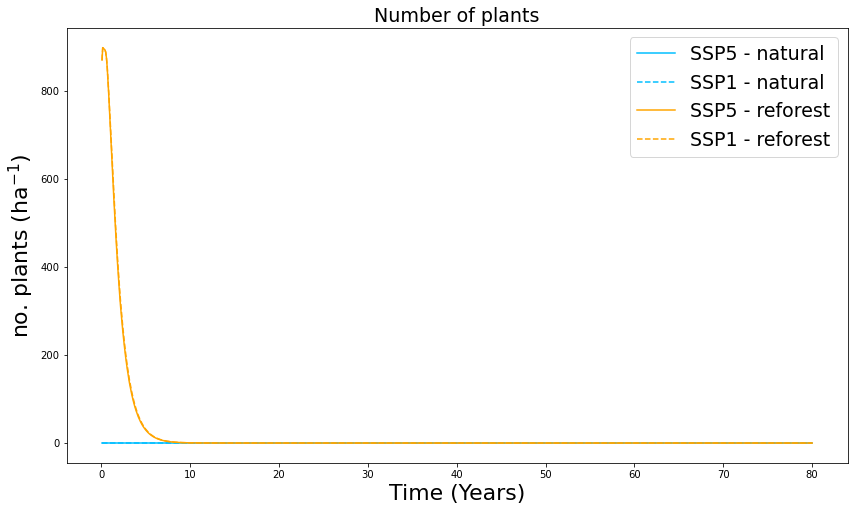

In [13]:
fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(14,8))

f1ax0.plot(time_nat, NPLANT_SZ_nat_ssp5,label = 'SSP5 - natural', color='deepskyblue')    
f1ax0.plot(time_nat, NPLANT_SZ_nat_ssp1,label = 'SSP1 - natural', linestyle='--', color='deepskyblue')    
f1ax0.plot(time_ref5, NPLANT_SZ_ref_ssp5, label = 'SSP5 - reforest', color='orange') 
f1ax0.plot(time_ref, NPLANT_SZ_ref_ssp1, label = 'SSP1 - reforest', linestyle='--', color='orange') 

f1ax0.set_title(r'Number of plants', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'no. plants (ha$^{-1}$)', fontsize=22)

f1ax0.legend(fontsize=19)